In [2]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_retail_sales_final.csv to cleaned_retail_sales_final.csv


In [3]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset (1).csv")
print("Dataset loaded!")
print(df.shape)
df.head()

Dataset loaded!
(1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [5]:
# Customer-level summary
customer = df.groupby("Customer ID").agg(
    total_spent=("Total Amount", "sum"),
    num_transactions=("Transaction ID", "count"),
    avg_transaction=("Total Amount", "mean"),
    age=("Age", "first"),
    gender=("Gender", "first"),
    total_quantity=("Quantity", "sum")
).reset_index()

# Most frequent product category per customer
def most_frequent_category(group):
    return group["Product Category"].mode().iloc[0]

top_category = df.groupby("Customer ID").apply(most_frequent_category).reset_index()
top_category.columns = ["Customer ID", "top_category"]

customer = customer.merge(top_category, on="Customer ID")

print(customer.shape)
customer.head()

(1000, 8)


/tmp/ipykernel_2236/2742257650.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_category = df.groupby("Customer ID").apply(most_frequent_category).reset_index()


,Customer ID,total_spent,num_transactions,avg_transaction,age,gender,total_quantity,top_category
0,CUST001,150,1,150.0,34,Male,3,Beauty
1,CUST002,1000,1,1000.0,26,Female,2,Clothing
2,CUST003,30,1,30.0,50,Male,1,Electronics
3,CUST004,500,1,500.0,37,Male,1,Clothing
4,CUST005,100,1,100.0,30,Male,2,Beauty


In [6]:
# Define thresholds (you can adjust later)
low_threshold = customer["total_spent"].quantile(0.33)
high_threshold = customer["total_spent"].quantile(0.67)

def assign_segment(x):
    if x <= low_threshold:
        return "Low-Value"
    elif x <= high_threshold:
        return "Medium-Value"
    else:
        return "High-Value"

customer["value_segment"] = customer["total_spent"].apply(assign_segment)

customer["value_segment"].value_counts()

,count
value_segment,
Medium-Value,352
Low-Value,349
High-Value,299


/tmp/ipykernel_2236/4254355789.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


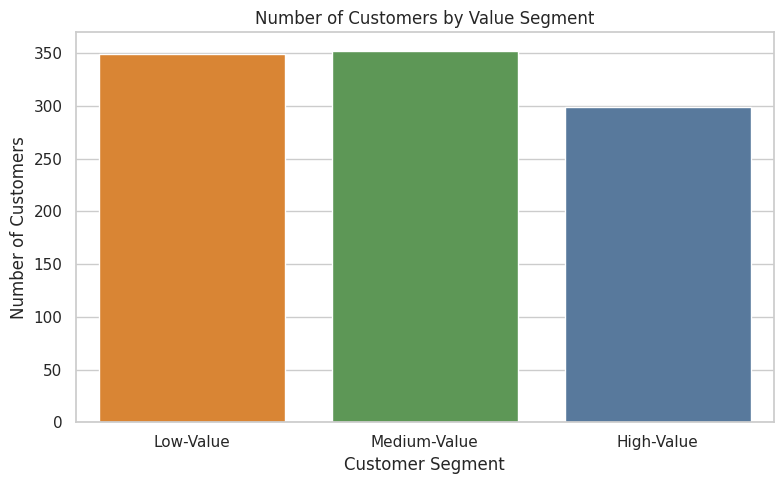

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(
    data=customer,
    x="value_segment",
    order=["Low-Value", "Medium-Value", "High-Value"],
    palette=["#F58518", "#54A24B", "#4C78A8"]
)
plt.title("Number of Customers by Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [8]:
segment_summary = customer.groupby("value_segment").agg(
    avg_total_spent=("total_spent", "mean"),
    avg_transactions=("num_transactions", "mean"),
    avg_age=("age", "mean")
).round(2)

segment_summary

,avg_total_spent,avg_transactions,avg_age
value_segment,,,
High-Value,1216.05,1.0,40.32
Low-Value,52.84,1.0,41.03
Medium-Value,210.11,1.0,42.66


High-Value customers: highest average spend and transactions; target with loyalty programmes.

Medium-Value customers: moderate spend; good candidates for upsell campaigns.

Low-Value customers: many small buyers; target with discounts to increase frequency.

In [9]:

customer.groupby(["value_segment", "gender"]).size().unstack(fill_value=0)

gender,Female,Male
value_segment,,
High-Value,155,144
Low-Value,178,171
Medium-Value,177,175


In [10]:
customer.to_csv("customer_segments.csv", index=False)
print("Customer segments saved as customer_segments.csv")

Customer segments saved as customer_segments.csv


In [11]:
from google.colab import files
files.download("customer_segments.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>